# EN3160 - Image Processing Assignment 1

**Name:** Hasith Nettikumara  
**Index Number:** 230436X  

This notebook contains the implementations and results for Assignment 1 on intensity transformations and neighborhood filtering.

In [1]:
%pip install matplotlib opencv-python numpy


[notice] A new release of pip is available: 24.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
# Folder containing the assignment images
IMAGE_DIR = Path("images")

# Check that the folder exists
print("Image directory exists:", IMAGE_DIR.exists())

Image directory exists: True


In [4]:
def show_image(image, title="", cmap=None, figsize=(6, 6)):
    plt.figure(figsize=figsize)

    if image.ndim == 3:
        # OpenCV loads color images in BGR format
        image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        plt.imshow(image_rgb)
    else:
        plt.imshow(image, cmap=cmap if cmap else "gray")

    plt.title(title)
    plt.axis("off")
    plt.show()

## Question 1 - Piecewise Linear Intensity Transformation

A piecewise linear intensity transformation is applied to the given grayscale image using a set of specified breakpoints. Linear interpolation is used to determine the output intensity values between consecutive breakpoints.

In [5]:
print("Available assignment images:")

for q1_available_image_path in IMAGE_DIR.iterdir():
    print(q1_available_image_path.name)

Available assignment images:
im01.png
im01small.png
im02.png
im02small.png
im03.png
im03small.png
im04.jpg
im04small.jpg
im05.jpg
q1.jpeg
q2.jpeg
shells.tif
WhatsApp Image 2026-09-09 at 20.02.43 (1).jpeg
WhatsApp Image 2026-09-09 at 20.02.43 (2).jpeg
WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg
WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg
WhatsApp Image 2026-09-09 at 20.02.44 (3).jpeg
WhatsApp Image 2026-09-09 at 20.02.441.jpeg


In [6]:
q1_portrait_file = IMAGE_DIR / "q1.jpeg"

q1_portrait_gray = cv.imread(
    str(q1_portrait_file),
    cv.IMREAD_GRAYSCALE
)

if q1_portrait_gray is None:
    raise FileNotFoundError(
        f"Could not load Question 1 image: {q1_portrait_file}"
    )

print("Image shape:", q1_portrait_gray.shape)
print("Image datatype:", q1_portrait_gray.dtype)
print("Minimum intensity:", q1_portrait_gray.min())
print("Maximum intensity:", q1_portrait_gray.max())

Image shape: (810, 720)
Image datatype: uint8
Minimum intensity: 0
Maximum intensity: 255


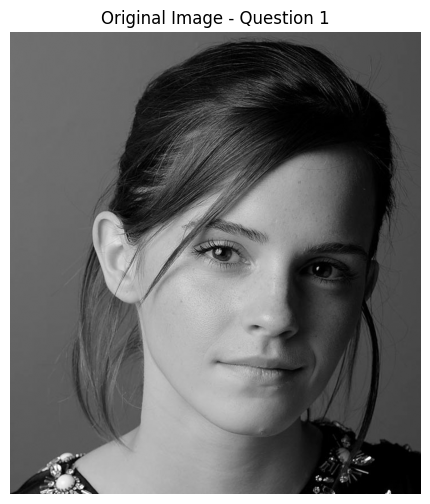

In [7]:
plt.figure(figsize=(6, 6))

plt.imshow(
    q1_portrait_gray,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Original Image - Question 1")
plt.axis("off")
plt.show()

In [8]:
q1_breakpoints_reference = np.array([
    [0,   0],
    [50,  50],
    [100, 150],
    [150, 255],
    [255, 255]
], dtype=np.float32)

q1_breakpoints_trial_a = np.array([
    [0,   0],
    [40,  30],
    [90,  110],
    [150, 210],
    [210, 245],
    [255, 255]
], dtype=np.float32)

q1_breakpoints_trial_b = np.array([
    [0,   0],
    [50,  25],
    [100, 125],
    [160, 220],
    [220, 250],
    [255, 255]
], dtype=np.float32)

q1_breakpoints_trial_c = np.array([
    [0,   0],
    [40,  30],
    [90,  100],
    [150, 175],
    [210, 225],
    [255, 255]
], dtype=np.float32)


q1_breakpoints_trial_d = np.array([
    [0,   0],
    [40,  28],
    [90,  98],
    [150, 168],
    [210, 222],
    [255, 255]
], dtype=np.float32)

q1_breakpoints_trial_e = np.array([
    [0,   0],
    [40,  32],
    [90,  102],
    [150, 170],
    [210, 220],
    [255, 255]
], dtype=np.float32)


In [9]:
def intensity_transform(im, breakpoints):
    input_levels = breakpoints[:, 0]
    output_levels = breakpoints[:, 1]

    transformed_image = np.interp(
        im.astype(np.float32),
        input_levels,
        output_levels
    )

    transformed_image = np.clip(
        transformed_image,
        0,
        255
    )

    return transformed_image.astype(np.uint8)

In [10]:
q1_output_reference = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_reference
)

q1_output_trial_a = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_a
)

q1_output_trial_b = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_b
)

q1_output_trial_c = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_c
)

q1_output_trial_d = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_d
)

q1_output_trial_e = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_e
)

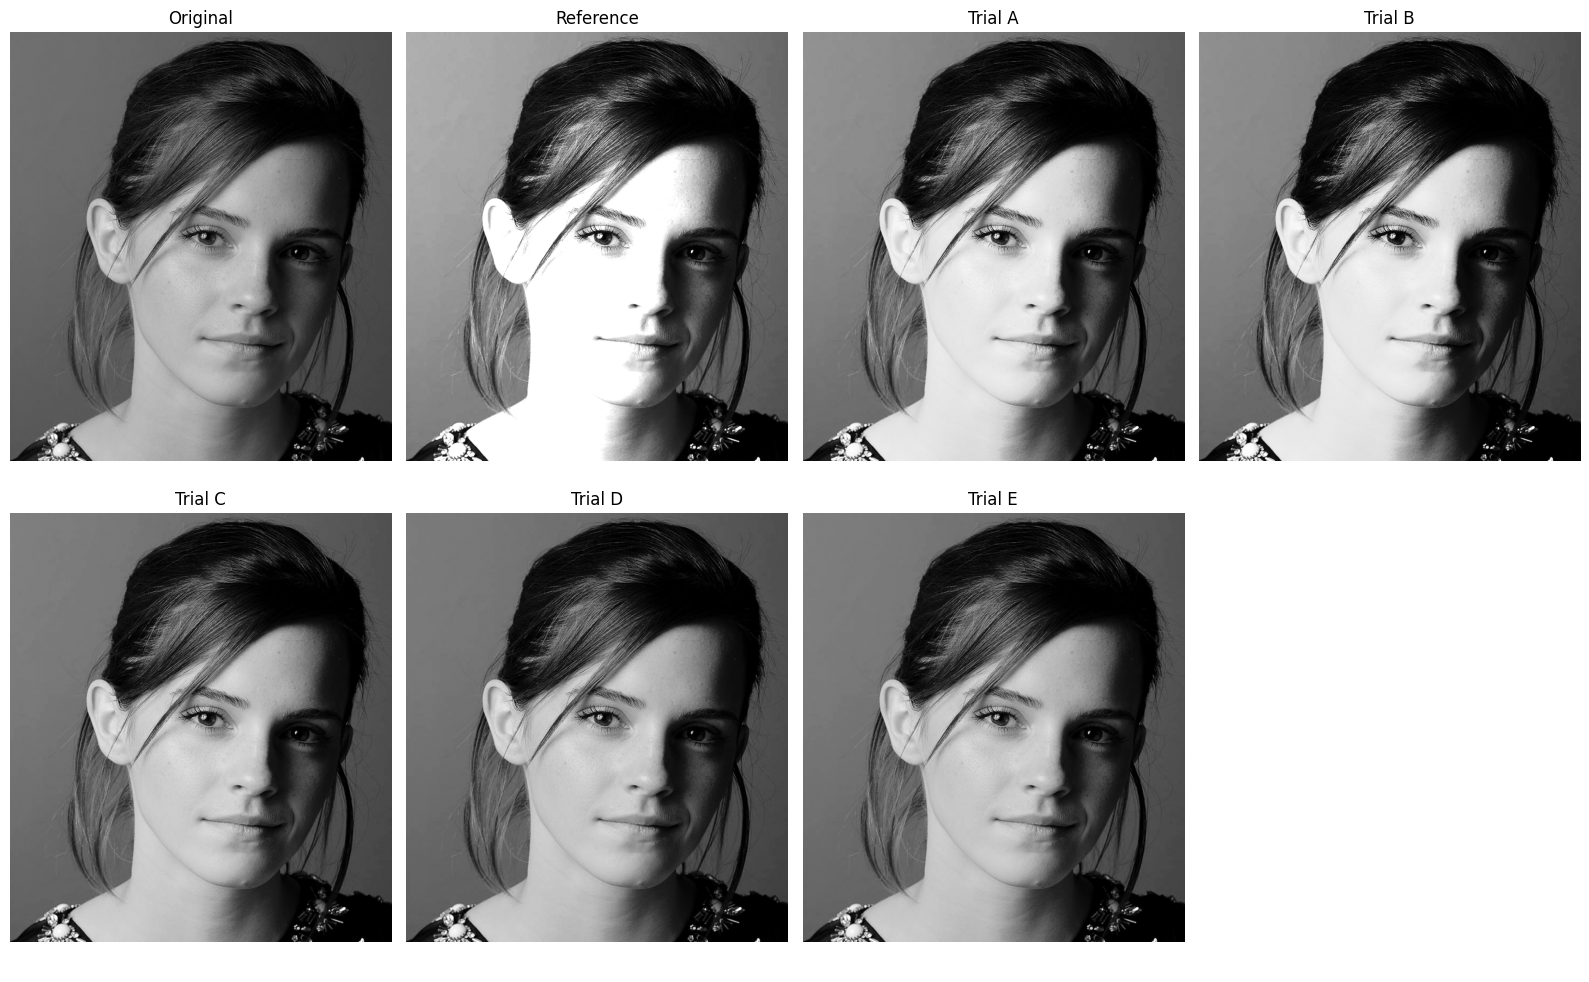

In [14]:
q1_trial_figure, q1_trial_axes = plt.subplots(
    2,
    4,
    figsize=(16, 10)
)

q1_trial_images = [
    q1_portrait_gray,
    q1_output_reference,
    q1_output_trial_a,
    q1_output_trial_b,
    q1_output_trial_c,
    q1_output_trial_d,
    q1_output_trial_e
]

q1_trial_titles = [
    "Original",
    "Reference",
    "Trial A",
    "Trial B",
    "Trial C",
    "Trial D",
    "Trial E"
]

# Flatten the 2x4 axes array so we can index it easily
q1_trial_axes_flat = q1_trial_axes.flatten()

for q1_panel_index in range(len(q1_trial_images)):

    q1_trial_axes_flat[q1_panel_index].imshow(
        q1_trial_images[q1_panel_index],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    q1_trial_axes_flat[q1_panel_index].set_title(
        q1_trial_titles[q1_panel_index]
    )

    q1_trial_axes_flat[q1_panel_index].axis("off")

# Hide the unused 8th subplot
q1_trial_axes_flat[-1].axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Select Trial D as the final intensity transformation
q1_selected_breakpoints = q1_breakpoints_trial_d.copy()

q1_selected_output = intensity_transform(
    q1_portrait_gray,
    q1_selected_breakpoints
)

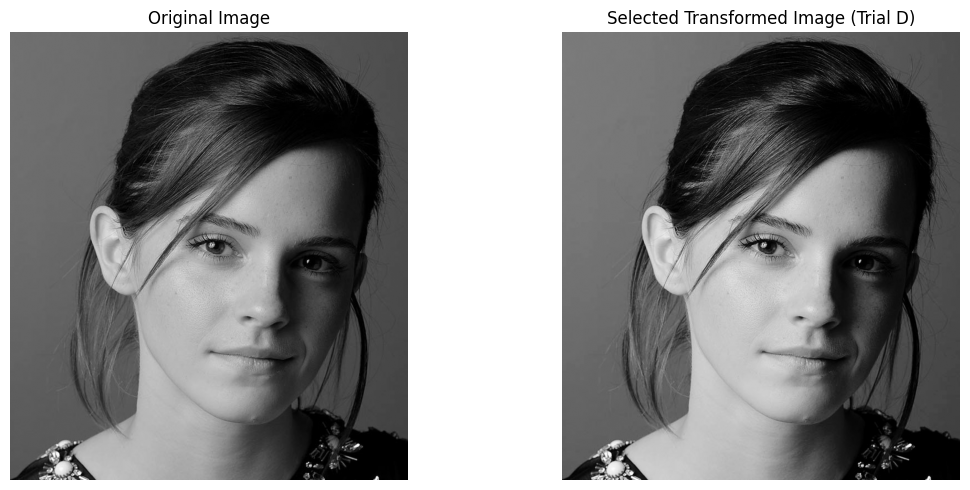

In [16]:
q1_final_figure, q1_final_axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Original image
q1_final_axes[0].imshow(
    q1_portrait_gray,
    cmap="gray",
    vmin=0,
    vmax=255
)

q1_final_axes[0].set_title("Original Image")
q1_final_axes[0].axis("off")


# Selected transformed image - Trial D
q1_final_axes[1].imshow(
    q1_selected_output,
    cmap="gray",
    vmin=0,
    vmax=255
)

q1_final_axes[1].set_title("Selected Transformed Image (Trial D)")
q1_final_axes[1].axis("off")

plt.tight_layout()
plt.show()

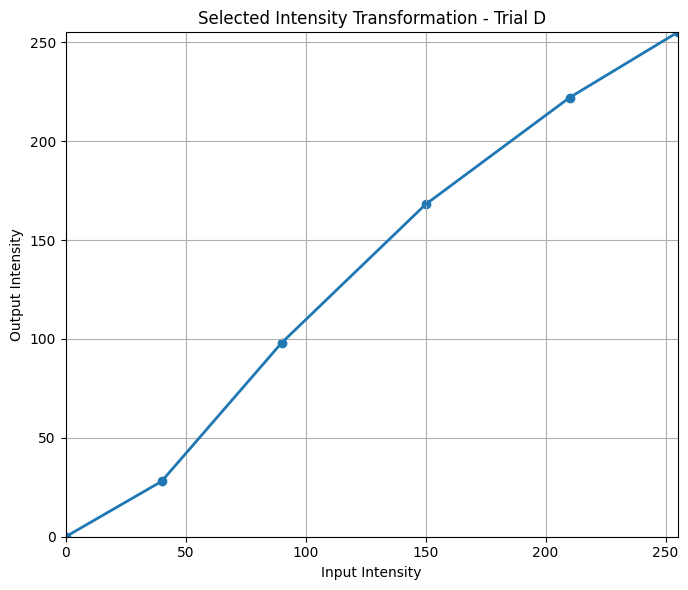

In [17]:
q1_selected_intensity_axis = np.arange(256)

q1_selected_mapping = np.interp(
    q1_selected_intensity_axis,
    q1_selected_breakpoints[:, 0],
    q1_selected_breakpoints[:, 1]
)

plt.figure(figsize=(7, 6))

plt.plot(
    q1_selected_intensity_axis,
    q1_selected_mapping,
    linewidth=2
)

plt.scatter(
    q1_selected_breakpoints[:, 0],
    q1_selected_breakpoints[:, 1]
)

plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.title("Selected Intensity Transformation - Trial D")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.tight_layout()
plt.show()

## Question 2 - White Matter and Gray Matter Enhancement

Piecewise linear intensity transformations are used to separately accentuate white matter and gray matter in the proton-density brain image.

The image intensity distribution is first examined to identify suitable intensity ranges for the two tissue types. Separate transformations are then designed for white matter and gray matter enhancement.

In [18]:
q2_brain_file = IMAGE_DIR / "q2.jpeg"

q2_brain_gray = cv.imread(
    str(q2_brain_file),
    cv.IMREAD_GRAYSCALE
)

if q2_brain_gray is None:
    raise FileNotFoundError(
        f"Could not load Question 2 image: {q2_brain_file}"
    )

print("Brain image shape:", q2_brain_gray.shape)
print("Brain image datatype:", q2_brain_gray.dtype)
print("Minimum intensity:", q2_brain_gray.min())
print("Maximum intensity:", q2_brain_gray.max())

Brain image shape: (217, 181)
Brain image datatype: uint8
Minimum intensity: 0
Maximum intensity: 251


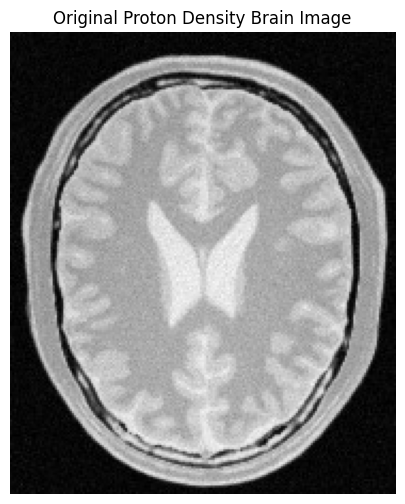

In [19]:
plt.figure(figsize=(6, 6))

plt.imshow(
    q2_brain_gray,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Original Proton Density Brain Image")
plt.axis("off")

plt.show()

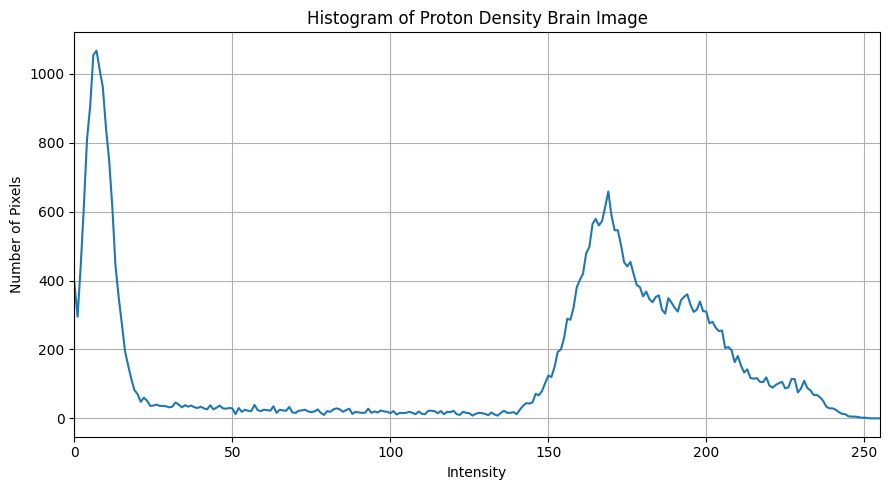

In [20]:
q2_histogram_counts, q2_histogram_bins = np.histogram(
    q2_brain_gray.flatten(),
    bins=256,
    range=(0, 256)
)

plt.figure(figsize=(9, 5))

plt.plot(
    np.arange(256),
    q2_histogram_counts
)

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Histogram of Proton Density Brain Image")

plt.xlim(0, 255)
plt.grid(True)

plt.tight_layout()
plt.show()

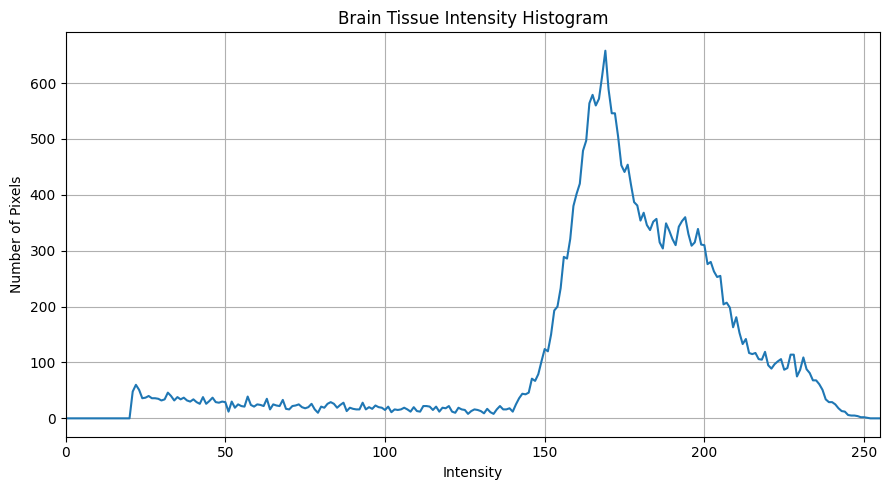

In [21]:
q2_tissue_pixels = q2_brain_gray[q2_brain_gray > 20]

q2_tissue_histogram, _ = np.histogram(
    q2_tissue_pixels,
    bins=256,
    range=(0, 256)
)

plt.figure(figsize=(9, 5))

plt.plot(
    np.arange(256),
    q2_tissue_histogram
)

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Brain Tissue Intensity Histogram")

plt.xlim(0, 255)
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
q2_percentile_levels = [5, 10, 25, 50, 75, 90, 95]

q2_tissue_percentiles = np.percentile(
    q2_tissue_pixels,
    q2_percentile_levels
)

for q2_percentile_label, q2_percentile_value in zip(
    q2_percentile_levels,
    q2_tissue_percentiles
):
    print(
        f"{q2_percentile_label:>2}th percentile: "
        f"{q2_percentile_value:.2f}"
    )

 5th percentile: 64.00
10th percentile: 141.00
25th percentile: 163.00
50th percentile: 175.00
75th percentile: 195.00
90th percentile: 211.00
95th percentile: 223.00


In [30]:
# Final piecewise-linear transformation for white matter enhancement
q2_white_matter_breakpoints = np.array([
    [0,   0],
    [120, 105],
    [145, 125],
    [160, 145],
    [180, 200],
    [200, 218],
    [225, 238],
    [255, 255]
], dtype=np.float32)


# Final piecewise-linear transformation for gray matter enhancement
q2_gray_matter_breakpoints = np.array([
    [0,   0],
    [135, 115],
    [165, 140],
    [185, 165],
    [205, 220],
    [225, 238],
    [255, 255]
], dtype=np.float32)

In [31]:
q2_white_matter_output = intensity_transform(
    q2_brain_gray,
    q2_white_matter_breakpoints
)

q2_gray_matter_output = intensity_transform(
    q2_brain_gray,
    q2_gray_matter_breakpoints
)

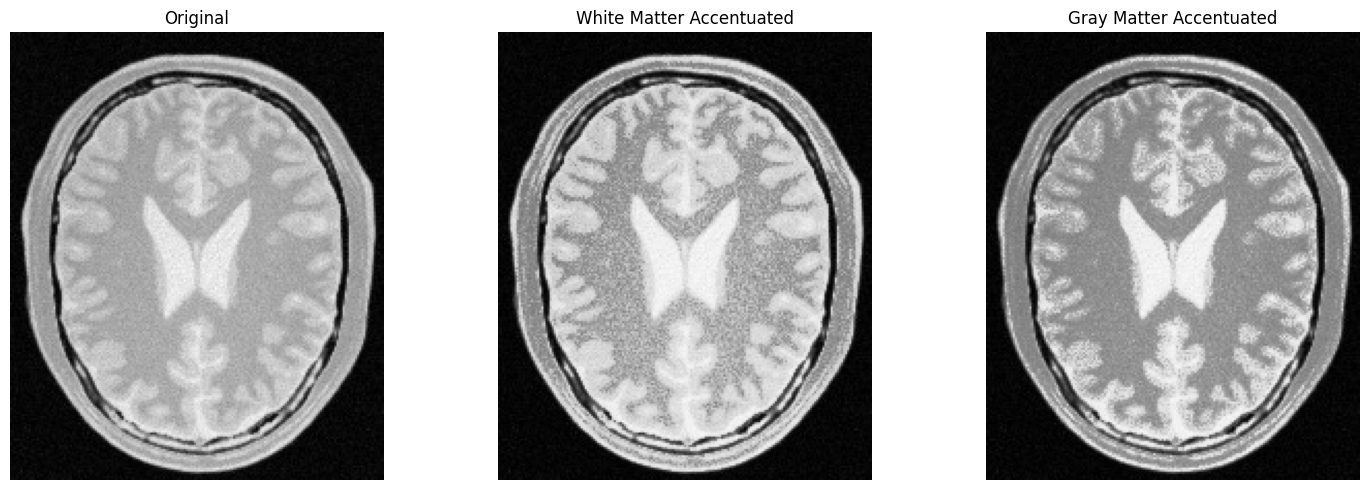

In [32]:
q2_final_figure, q2_final_axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

q2_final_images = [
    q2_brain_gray,
    q2_white_matter_output,
    q2_gray_matter_output
]

q2_final_titles = [
    "Original",
    "White Matter Accentuated",
    "Gray Matter Accentuated"
]

for q2_final_index in range(3):

    q2_final_axes[q2_final_index].imshow(
        q2_final_images[q2_final_index],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    q2_final_axes[q2_final_index].set_title(
        q2_final_titles[q2_final_index]
    )

    q2_final_axes[q2_final_index].axis("off")

plt.tight_layout()
plt.show()

In [33]:
q2_intensity_axis = np.arange(256)

q2_white_matter_curve = np.interp(
    q2_intensity_axis,
    q2_white_matter_breakpoints[:, 0],
    q2_white_matter_breakpoints[:, 1]
)

q2_gray_matter_curve = np.interp(
    q2_intensity_axis,
    q2_gray_matter_breakpoints[:, 0],
    q2_gray_matter_breakpoints[:, 1]
)

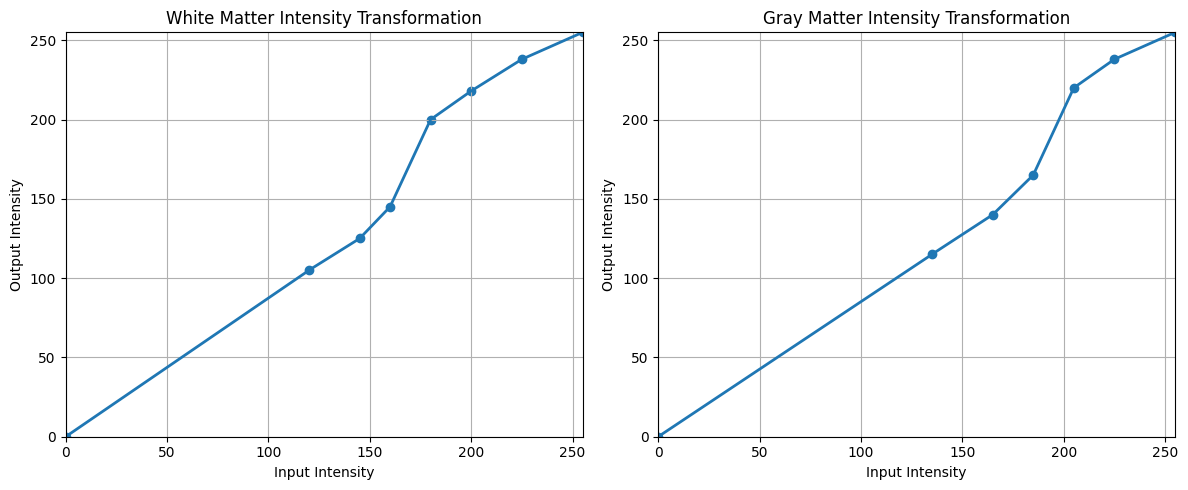

In [34]:
q2_transform_figure, q2_transform_axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# White matter transformation
q2_transform_axes[0].plot(
    q2_intensity_axis,
    q2_white_matter_curve,
    linewidth=2
)

q2_transform_axes[0].scatter(
    q2_white_matter_breakpoints[:, 0],
    q2_white_matter_breakpoints[:, 1]
)

q2_transform_axes[0].set_title(
    "White Matter Intensity Transformation"
)

q2_transform_axes[0].set_xlabel("Input Intensity")
q2_transform_axes[0].set_ylabel("Output Intensity")

q2_transform_axes[0].set_xlim(0, 255)
q2_transform_axes[0].set_ylim(0, 255)
q2_transform_axes[0].grid(True)


# Gray matter transformation
q2_transform_axes[1].plot(
    q2_intensity_axis,
    q2_gray_matter_curve,
    linewidth=2
)

q2_transform_axes[1].scatter(
    q2_gray_matter_breakpoints[:, 0],
    q2_gray_matter_breakpoints[:, 1]
)

q2_transform_axes[1].set_title(
    "Gray Matter Intensity Transformation"
)

q2_transform_axes[1].set_xlabel("Input Intensity")
q2_transform_axes[1].set_ylabel("Output Intensity")

q2_transform_axes[1].set_xlim(0, 255)
q2_transform_axes[1].set_ylim(0, 255)
q2_transform_axes[1].grid(True)


plt.tight_layout()
plt.show()

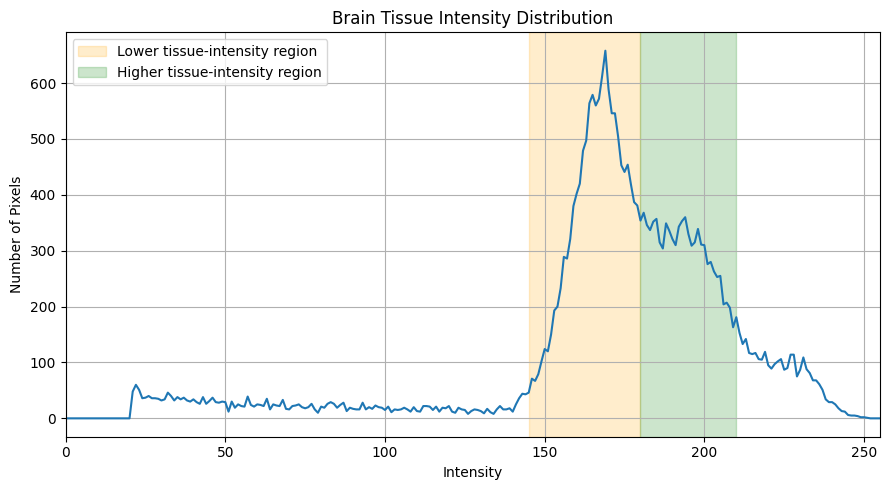

In [36]:
plt.figure(figsize=(9, 5))

plt.plot(
    np.arange(256),
    q2_tissue_histogram,
    linewidth=1.5
)

# Lower tissue-intensity region
plt.axvspan(
    145,
    180,
    alpha=0.20,
    color="orange",
    label="Lower tissue-intensity region"
)

# Higher tissue-intensity region
plt.axvspan(
    180,
    210,
    alpha=0.20,
    color="green",
    label="Higher tissue-intensity region"
)

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Brain Tissue Intensity Distribution")

plt.xlim(0, 255)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Discussion

The histogram shows that most of the relevant brain-tissue intensities are concentrated approximately within the mid-to-high intensity range. Two intensity regions were therefore selected from the histogram to guide the design of the transformations.

Two separate piecewise-linear intensity transformations were designed. The first increases the contrast predominantly within the lower selected tissue-intensity range, with the aim of accentuating white matter. The second places stronger contrast enhancement within the higher selected tissue-intensity range, with the aim of accentuating gray matter. These intensity ranges are used as approximate enhancement regions rather than strict tissue-segmentation boundaries.

The transformations were kept gradual outside the selected ranges in order to preserve the overall anatomical appearance of the proton-density image and avoid excessive saturation caused by stronger contrast mappings.